In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import classification_report, confusion_matrix

import joblib

import warnings
warnings.filterwarnings('ignore')
"""
The Python statement import warnings; warnings.filterwarnings('ignore') serves to suppress or hide all warning 
messages that might otherwise be displayed during the execution of a Python program
"""

"\nThe Python statement import warnings; warnings.filterwarnings('ignore') serves to suppress or hide all warning \nmessages that might otherwise be displayed during the execution of a Python program\n"

## Data Ingestion

In [66]:
df=pd.read_csv(r"C:\Users\Aswin\Downloads\Consumer_Complaints.csv\Consumer_Complaints.csv")

In [4]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer Complaint,Company Public Response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Sent to Company,Company Response to Consumer,Timely response?,Consumer disputed?,Complaint ID
0,3/12/14,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/14,Closed with explanation,Yes,No,759217
1,10/1/16,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/16,Closed with explanation,Yes,No,2141773
2,10/17/16,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/16,Closed with explanation,Yes,No,2163100
3,6/8/14,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,6/10/14,Closed with explanation,Yes,Yes,885638
4,9/13/14,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,9/13/14,Closed with explanation,Yes,Yes,1027760


In [27]:
# Original dataset shape

df.shape

(9999, 18)

In [28]:
# taking only the required columns for the NLP application

df_=df.iloc[:,[1,5]].reset_index(drop=True)

In [29]:
# Dataset for Complaint Classification

# 1. Product(column)     ====> TARGET
# 2. Consumer Complaint  ====> FEATURE

df_.head()

,Product,Consumer Complaint
0,Mortgage,NaN
1,Credit reporting,I have outdated information on my credit repor...
2,Consumer Loan,I purchased a new car on XXXX XXXX. The car de...
3,Credit card,NaN
4,Debt collection,NaN


## Pre Processing

In [30]:
df_.shape

(9999, 2)

In [33]:
# Checking for Null/NaN in the dataset


print("no: of NaN in feature column: ",int(df_['Consumer Complaint'].isna().sum()))

no: of NaN in feature column:  7885


In [35]:
# Dropping all the NaN in the feature column

df_ = df_.dropna(subset=['Consumer Complaint']).reset_index(drop=True)

In [36]:
# Removing the NaN 

print("AFTER REMOVING THE NaN")
print("no: of NaN in feature column: ",int(df_['Consumer Complaint'].isna().sum()))

AFTER REMOVING THE NaN
no: of NaN in feature column:  0


In [38]:
df_.shape[0]

2114

In [44]:
print("All the classes in the Target column\n")
print(df_.Product.value_counts())

All the classes in the Target column

Product
Debt collection                                                                 519
Mortgage                                                                        407
Credit reporting                                                                395
Credit card                                                                     270
Bank account or service                                                         185
Student loan                                                                    145
Consumer Loan                                                                   108
Payday loan                                                                      26
Money transfers                                                                  22
Prepaid card                                                                     18
Credit reporting, credit repair services, or other personal consumer reports      9
Other financial service       

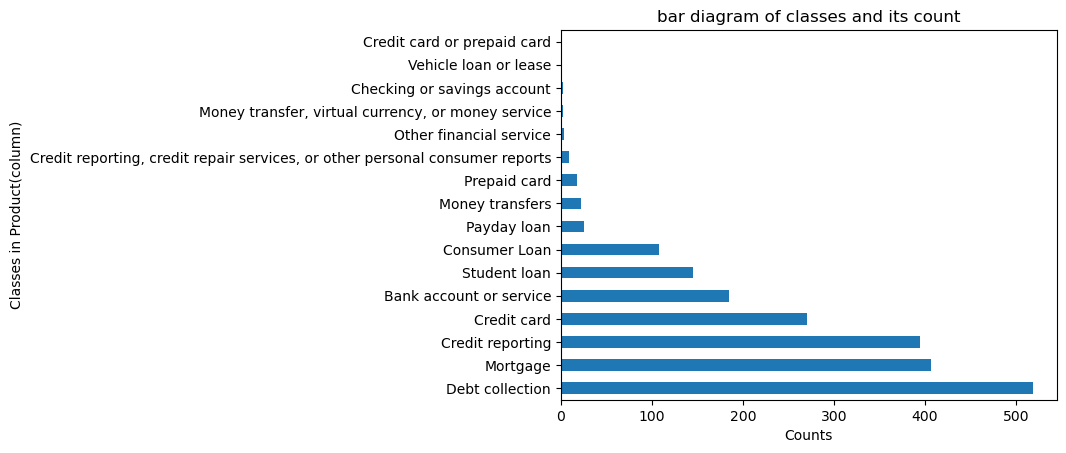

In [90]:
plt.title("bar diagram of classes and its count")
df_['Product'].value_counts().plot(kind='barh')
plt.ylabel('Classes in Product(column)')
plt.xlabel('Counts')
plt.show()

In [46]:
# Taking out the classes names that are needed and has greater number of data

classes=dict(df_.Product.value_counts())
classes=list(classes.keys())

categories_to_drop=classes[0:7]

In [57]:
categories_to_drop

['Debt collection',
 'Mortgage',
 'Credit reporting',
 'Credit card',
 'Bank account or service',
 'Student loan',
 'Consumer Loan']

In [61]:
# Retaining all the needed classes for the training

clean_df= df_[df_['Product'].isin(categories_to_drop)].reset_index(drop=True)

In [62]:
clean_df.head(5)

,Product,Consumer Complaint
0,Credit reporting,I have outdated information on my credit repor...
1,Consumer Loan,I purchased a new car on XXXX XXXX. The car de...
2,Credit reporting,An account on my credit report has a mistaken ...
3,Debt collection,This company refuses to provide me verificatio...
4,Debt collection,This complaint is in regards to Square Two Fin...


In [73]:
clean_df.Product.value_counts()

Product
Debt collection            519
Mortgage                   407
Credit reporting           395
Credit card                270
Bank account or service    185
Student loan               145
Consumer Loan              108
Name: count, dtype: int64

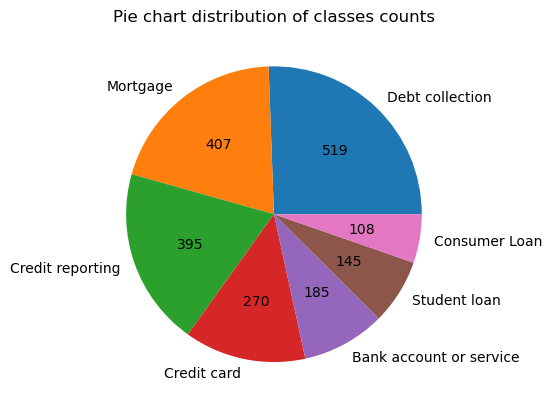

In [91]:
# 2. Plot with count function inside autopct

plt.title("Pie chart distribution of classes counts")
clean_df['Product'].value_counts().plot(kind='pie',autopct=lambda x: f'{int(x * counts.sum() / 100)}',ylabel='')
plt.show()


In [94]:
clean_df['Consumer Complaint'][6]

'In XXXX, I and my ex-husband applied for a refinance & HELOC from Beneficial. The loans were granted. My ex-husband passed away XXXX XXXX. At this time I contacted a lawyer to determine my options for having my husband removed from the title to the property and mortgage. Lawyer took care of having husband removed from the title. I recently attempted to apply for refinance to remove him from the mortgage and take cash out. I learned through an attempt to refinance I was unable to refinance the property due to there is no deed from XXXX found indicating my interest in the property. The only deed filed with the XXXX County Illinois Recorder was in XXXX with the original purchase of the home in which my ex-husband was the only one listed on the deed. Beneficial did file a mortgage on XXXX, XXXX on the property. I am just outraged at this point that I took out a loan on my home, yet it was never deeded in my name as one of the rightful owners. Now I am being denied the ability to refinance

In [13]:

df_['Consumer Complaint'][5]

'Started the refinance of home mortgage process with cash out option on XX/XX/2016. Necessary documents were submitted by XXXX. After initial review, got good faith estimate with loan amount and closing cost. Based on this estimate, a deposit of {$350.00} was made towards appraisal. Appraisal came with lesser amount by {$5000.00}. Agreed to reduce the loan amount to that extent. However, got a revised estimate which was less by {$30000.00} and with additional closing cost towards points etc. In between got numerous revised estimates with different loan amounts and closing cost. It took more than 2 months to reach any definite closing document. Hence, want to get back the deposit of {$350.00}.'

In [92]:
Consumer_Loan['Consumer Complaint'][101]

'The car was a voluntary repo back in 2008 and should be reported as closed and not an open collection file on my credit file, several attempts made to correct my credit file and the file should not be reported since its over 7 yrs old.'

In [93]:
# Save the DataFrame to a CSV file
clean_df.to_csv('D:\Datasets\complaint priority\cleaned_data.csv', index=False)

## preprocessed dataset ingestion

In [4]:
dff=pd.read_csv(r"D:\Datasets\complaint priority\preprocessed_complaints.csv")

In [5]:
dff.head(5)

,stopwords_cleaned_complaint,Product
0,outdate information credit report previously d...,Credit reporting
1,purchase new car car dealer day payoff good de...,Consumer Loan
2,credit report mistaken date mail debt validati...,Credit reporting
3,refuse provide verification validation debt ri...,Debt collection
4,regard square financial refer cfpb regard cach...,Debt collection


In [6]:
dff.stopwords_cleaned_complaint.isna().sum()

np.int64(1)

In [7]:
# Drops rows where 'text_column' contains NaN
dff.dropna(subset=['stopwords_cleaned_complaint'],inplace=True)

In [8]:
dff.stopwords_cleaned_complaint.isna().sum()

np.int64(0)

In [10]:
# label encoding the classes in the target column(Product)
from sklearn.preprocessing import LabelEncoder

labeling_columns=['Product']

for col in labeling_columns:
    labeling=LabelEncoder()
    dff[col]=labeling.fit_transform(dff[col])
    classes_dict=dict(zip(labeling.classes_, labeling.transform(labeling.classes_)))

In [11]:
# label encoded target column

dff.head()

,stopwords_cleaned_complaint,Product
0,outdate information credit report previously d...,3
1,purchase new car car dealer day payoff good de...,1
2,credit report mistaken date mail debt validati...,3
3,refuse provide verification validation debt ri...,4
4,regard square financial refer cfpb regard cach...,4


In [66]:
# the classes and its labels

classes_dict

{'Bank account or service': np.int64(0),
 'Consumer Loan': np.int64(1),
 'Credit card': np.int64(2),
 'Credit reporting': np.int64(3),
 'Debt collection': np.int64(4),
 'Mortgage': np.int64(5),
 'Student loan': np.int64(6)}

In [13]:
dff.Product.value_counts()

Product
4    518
5    407
3    395
2    270
0    185
6    145
1    108
Name: count, dtype: int64

# train test split

In [14]:
from sklearn.model_selection import train_test_split
x=dff.stopwords_cleaned_complaint
y=dff.Product

# Stratify ensures your test set perfectly mirrors your training set distribution
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,stratify=y,random_state=42)

In [15]:
x_train.head(3)

1773    set payment reminder online banking statement ...
796     write check money mail check universal recover...
1240    national collection bureau debt pay credit report
Name: stopwords_cleaned_complaint, dtype: object

In [16]:
y_train.head(3)

1773    2
796     1
1240    4
Name: Product, dtype: int64

In [17]:
x_test.tail(2)

1195    debt discharge court harrasse money security d...
1947    attempt payment private sallie mae instance pa...
Name: stopwords_cleaned_complaint, dtype: object

In [18]:
y_test.tail(2)

1195    4
1947    6
Name: Product, dtype: int64

## vectorizer

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2500,norm='l2',min_df=2,ngram_range=(1, 2))

x_train_vector = vectorizer.fit_transform(x_train)
x_test_vector = vectorizer.transform(x_test)

In [67]:
joblib.dump(vectorizer, "vectorizer_for_compliant_NB.pkl")

['vectorizer_for_compliant_NB.pkl']

In [20]:
x_train_vector.shape

(1825, 2500)

In [21]:
x_train_vector.shape

(1825, 2500)

In [22]:
class_counts = pd.Series(y_train).value_counts().to_dict()

In [23]:
class_counts

{4: 466, 5: 366, 3: 355, 2: 243, 0: 167, 6: 131, 1: 97}

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

sampling_pipeline = Pipeline([('under', RandomUnderSampler(sampling_strategy='majority', random_state=42)),
                              ('over', SMOTE(sampling_strategy='all', random_state=42))
                             ])

In [25]:
x_train_balanced, y_train_balanced = sampling_pipeline.fit_resample(x_train_vector, y_train)

## Model Building

In [28]:
# MultinomialNB(plain) without any tuning

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train_balanced, y_train_balanced)

MultinomialNB()

In [29]:
y_pred = model.predict(x_test_vector)

In [30]:
# classification report of naive bayes without param tuning

cp=classification_report(y_test, y_pred)

In [31]:
print(cp)

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        18
           1       0.38      0.45      0.42        11
           2       0.74      0.74      0.74        27
           3       0.75      0.90      0.82        40
           4       0.85      0.67      0.75        52
           5       0.95      0.85      0.90        41
           6       0.67      0.86      0.75        14

    accuracy                           0.77       203
   macro avg       0.73      0.75      0.73       203
weighted avg       0.79      0.77      0.78       203



In [32]:
cm=confusion_matrix(y_test, y_pred)

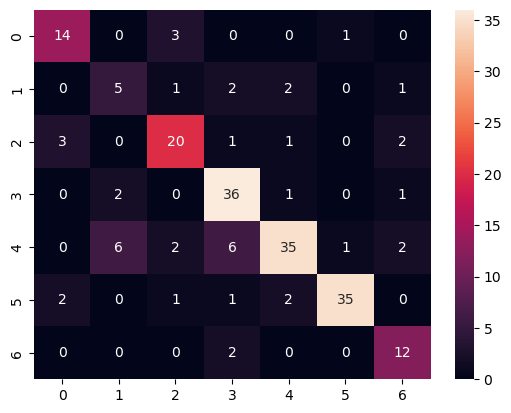

In [33]:
# confusion matrix of normal MultinomialNB

sns.heatmap(cm,annot=True)
plt.show()

In [40]:
# XGBClassifier(plain) without any tuning

from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=200)
xgb.fit(x_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [41]:
y_pred_simple_xgb = model.predict(x_test_vector)

In [42]:
# classification report of XGBClassifier without param tuning

cp_xgb=classification_report(y_test, y_pred)

In [44]:
print(cp_xgb)

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        18
           1       0.38      0.45      0.42        11
           2       0.74      0.74      0.74        27
           3       0.75      0.90      0.82        40
           4       0.85      0.67      0.75        52
           5       0.95      0.85      0.90        41
           6       0.67      0.86      0.75        14

    accuracy                           0.77       203
   macro avg       0.73      0.75      0.73       203
weighted avg       0.79      0.77      0.78       203



In [45]:
# confusion matrix of XGBClassifier without param tuning

cm_xgb=confusion_matrix(y_test, y_pred_simple_xgb)

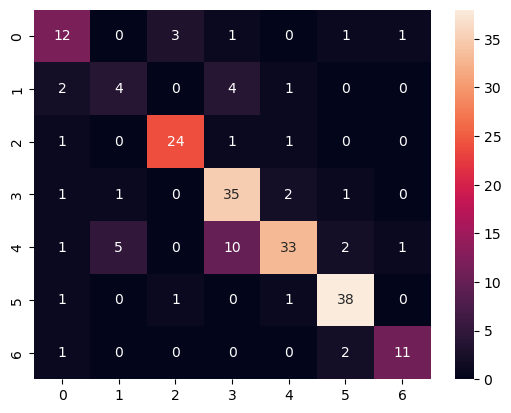

In [46]:
sns.heatmap(cm,annot=True)
plt.show()

In [49]:
# randomsearchCv for MultinomialNB

nb_model = MultinomialNB()

param_distributions = {'alpha': np.logspace(-3, 1, 100),'fit_prior': [True, False]}


nb_random_search = RandomizedSearchCV(estimator=nb_model,param_distributions=param_distributions,
                                      n_iter=20,scoring='f1_macro',cv=5,
                                      verbose=1,random_state=42,n_jobs=-1)           

In [50]:
nb_random_search.fit(x_train_balanced, y_train_balanced)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=MultinomialNB(), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': array([1.00000000e-03, 1.09749877e-03, 1.20450354e-03, 1.32194115e-03,
       1.45082878e-03, 1.59228279e-03, 1.74752840e-03, 1.91791026e-03,
       2.10490414e-03, 2.31012970e-03, 2.53536449e-03, 2.78255940e-03,
       3.05385551e-03, 3.35160265e-03, 3.67837977e-03, 4.03701726e-03,
       4.43...
       1.70735265e+00, 1.87381742e+00, 2.05651231e+00, 2.25701972e+00,
       2.47707636e+00, 2.71858824e+00, 2.98364724e+00, 3.27454916e+00,
       3.59381366e+00, 3.94420606e+00, 4.32876128e+00, 4.75081016e+00,
       5.21400829e+00, 5.72236766e+00, 6.28029144e+00, 6.89261210e+00,
       7.56463328e+00, 8.30217568e+00, 9.11162756e+00, 1.00000000e+01]),
                                        'fit_prior': [True, False]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [51]:
print(nb_random_search.best_params_)

{'fit_prior': True, 'alpha': np.float64(0.013530477745798075)}


In [53]:
best_nb_model = nb_random_search.best_estimator_
y_pred_nb = best_nb_model.predict(x_test_vector)

In [54]:
# classification report of hyper parameter tuned MultinomialNB

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69        18
           1       0.33      0.27      0.30        11
           2       0.65      0.74      0.69        27
           3       0.65      0.93      0.76        40
           4       0.87      0.38      0.53        52
           5       0.75      0.93      0.83        41
           6       0.73      0.79      0.76        14

    accuracy                           0.69       203
   macro avg       0.67      0.67      0.65       203
weighted avg       0.72      0.69      0.67       203



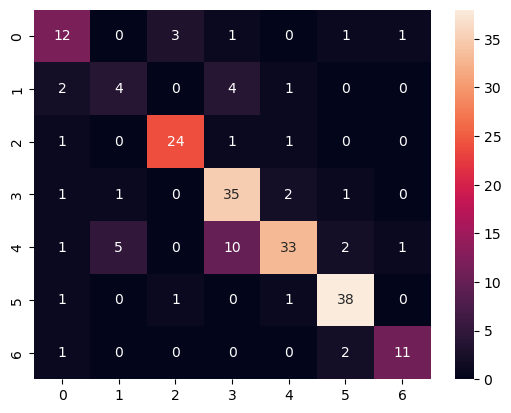

In [55]:
# confusion matrix of hyper parameter tuned MultinomialNB

cm_nb=confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm,annot=True)
plt.show()

In [34]:
# randomsearchCv for XGBClassifier

xgb_model = XGBClassifier(tree_method='hist', eval_metric='mlogloss',random_state=42)

param_distributions = {'n_estimators': [100, 200, 300],'learning_rate': [0.01, 0.05, 0.1],
                       'max_depth': [3, 5, 7],'subsample': [0.7, 0.8, 0.9],
                       'colsample_bytree': [0.6, 0.7, 0.8],'gamma': [0, 0.1, 0.2]
                      }

xgb_random_search = RandomizedSearchCV(estimator=xgb_model,param_distributions=param_distributions,
                                       n_iter=10,scoring='accuracy',cv=5,verbose=2,
                                       random_state=42,n_jobs=-1)


In [35]:
xgb_random_search.fit(x_train_balanced, y_train_balanced)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='accuracy', verbose=2)

In [36]:
print(xgb_random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [37]:
best_xgb_model = xgb_random_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(x_test_vector)

In [38]:
# classification report of hyper parameter tuned XGBClassifier

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65        18
           1       0.40      0.36      0.38        11
           2       0.86      0.89      0.87        27
           3       0.69      0.88      0.77        40
           4       0.87      0.63      0.73        52
           5       0.86      0.93      0.89        41
           6       0.85      0.79      0.81        14

    accuracy                           0.77       203
   macro avg       0.74      0.73      0.73       203
weighted avg       0.78      0.77      0.77       203



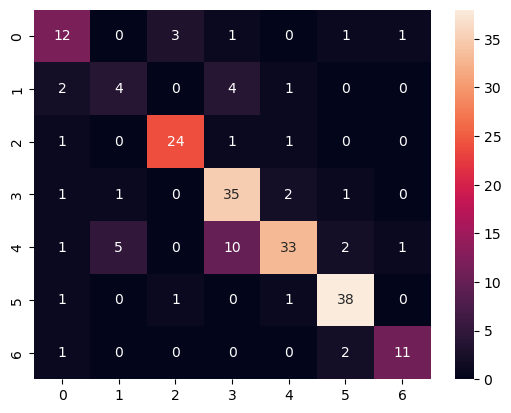

In [39]:
# confusion matrix of hyper parameter tuned XGBClassifier

cm=confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm,annot=True)
plt.show()

## Model conclusion

the plain MultinomialNB model and hyper parameter tuned XGBClassifier share same accuracy score with 77%,
but must consider the f1 scores and class performance in both the model with the classifications reports.

In [61]:
print("MultinomialNB( Normal )\n")
print(cp)

MultinomialNB( Normal )

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        18
           1       0.38      0.45      0.42        11
           2       0.74      0.74      0.74        27
           3       0.75      0.90      0.82        40
           4       0.85      0.67      0.75        52
           5       0.95      0.85      0.90        41
           6       0.67      0.86      0.75        14

    accuracy                           0.77       203
   macro avg       0.73      0.75      0.73       203
weighted avg       0.79      0.77      0.78       203



In [62]:
print("XGBClassifier ( TUNED )\n")
print(classification_report(y_test, y_pred_xgb))

XGBClassifier ( TUNED )

              precision    recall  f1-score   support

           0       0.63      0.67      0.65        18
           1       0.40      0.36      0.38        11
           2       0.86      0.89      0.87        27
           3       0.69      0.88      0.77        40
           4       0.87      0.63      0.73        52
           5       0.86      0.93      0.89        41
           6       0.85      0.79      0.81        14

    accuracy                           0.77       203
   macro avg       0.74      0.73      0.73       203
weighted avg       0.78      0.77      0.77       203



## Model saving

In [65]:
joblib.dump(model,"Compliant_NB.joblib")

['Compliant_NB.joblib']